In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.interpolate import interp1d

from fisherA2Z.fisher_flex import FisherFlex
from fisherA2Z import nz_decomposition as nzd
import tables_io
from scipy.interpolate import interp1d

%matplotlib inline
plt.rcParams["figure.dpi"] = 110

In [2]:
nz_dict = tables_io.read('./nz_challenge_taskset_1_cardinal_1yr_nz_estimate_wfd.hdf5')

### calculate the effective number density

In [3]:


N_OBJECTS = dict(
    taskset_1 = dict(
        flagship_1yr = 3625282,
        flagship_4yr = 3617704,
        cardinal_1yr = 3505864,
        cardinal_4yr = 3500333,
    ),
    taskset_2 = dict(
        flagship_1yr = 21227337,
        flagship_4yr = 22302511,
        cardinal_1yr = 17424236,
        cardinal_4yr = 18170490,
    ),
)

# For the WFD files we selection 1M objects from the catalogs
N_SAMPLED_OBJ = 1000000

# This is the total area of the sims (32 HEALPix nside=32 pixels)
# That corresponds to 32 / (12 * 32 * 32) = 0.002604166667 of the sky
SIM_SKY_AREA = 107.4295
SIM_SKY_AREA_MIN2 = 107.4295 * 3600

# These are the sampling factors, i.e., number of catalog objects / number sampled
SAMPLING_RATIO = dict(
    taskset_1 = {key: n_obj / N_SAMPLED_OBJ for key, n_obj in N_OBJECTS['taskset_1'].items()},
    taskset_2 = {key: n_obj / N_SAMPLED_OBJ for key, n_obj in N_OBJECTS['taskset_2'].items()},
)

# This is the effective density for total number of sampled objects
TOTAL_EFFECTIVE_DENSITY = dict(
    taskset_1 = {key: n_obj / SIM_SKY_AREA_MIN2 for key, n_obj in N_OBJECTS['taskset_1'].items()},
    taskset_2 = {key: n_obj / SIM_SKY_AREA_MIN2 for key, n_obj in N_OBJECTS['taskset_2'].items()},
)

def tomo_bins_effective_density(
    n_objects: np.ndarray,
    taskset: str,
    sim: str,
    scenario: str,
) -> np.ndarray:
    """Compute the effective number density for the tomographic bins

    Parameter
    ---------
    n_objects
        Number of objects in each bin
    taskset
        Name of the taskset
    sim
        Name of the simulation ('cardinal' or 'flagship')
    scenario
        Name of the scenario ('1yr' or '4yr')

    Returns
    -------
    Effective number density (in gal / min^2)
    """
    conversion = TOTAL_EFFECTIVE_DENSITY[taskset][f"{sim}_{scenario}"]
    return n_objects*conversion/N_SAMPLED_OBJ

neff = tomo_bins_effective_density(nz_dict['ancil']['n_object'], 'taskset_1', 'cardinal', '1yr')

### grab the central n(z) and the zgrid

In [4]:
nz_central = nz_dict['data']['pdfs']
z_grid = np.linspace(0.02, 3.0, 150)
z_grid_repeat = np.repeat(z_grid, 100).reshape(150, 100).T

### here we generate some realizations but I think we should require this from people

In [5]:
nz_shifted = []
for i in range(5):
    f = interp1d(z_grid, nz_central[i], kind='cubic', bounds_error=False, fill_value=0.0)
    
    shift = np.random.normal(0,0.02,100)
    shift_repeat = np.repeat(shift, 150).reshape(100, 150)


    nz_realizations = f(z_grid_repeat + shift_repeat)
    nz_shifted.append(nz_realizations)

nz_shifted = np.array(nz_shifted)

nz_shifted = np.swapaxes(nz_shifted, 0,1)
# shift.shape

In [7]:
flex_y1_cs = FisherFlex(
    # -- the n(z) and its uncertainty ---------------------------------
    nz_source=nz_central,
    nz_realizations=nz_shifted,
    z_grid=z_grid,
    # -- the survey ---------------------------------------------------
    neff_source=neff,   # arcmin^-2, per tomographic bin
    fsky=0.5,                        # ~0.5
    sigma_e=0.26,                       # per-component ellipticity dispersion
    # -- the analysis -------------------------------------------------
    mode="cosmic_shear",                       # or '2x2pt' / 'cosmic_shear'
    nz_model="shift_stretch",           # the default; see below for the alternative
)

flex_y1_cs.compute(parallel=True)

res_y1_cs = flex_y1_cs.forecast(ell_max_cs=1800, ell_min_cs=300)

s8, s8_err = res_y1_cs.s8()
print(f"LSSTY1 cosmic shear S_8 = {s8:.4f} +/- {s8_err:.4f}")

Measuring the shift and stretch of 100 realizations ...
Computing the fiducial data vector and covariance ...
Computing derivatives for 31 parameters (parallel) ...
Done.
LSSTY1 cosmic shear S_8 = 0.8523 +/- 0.0166


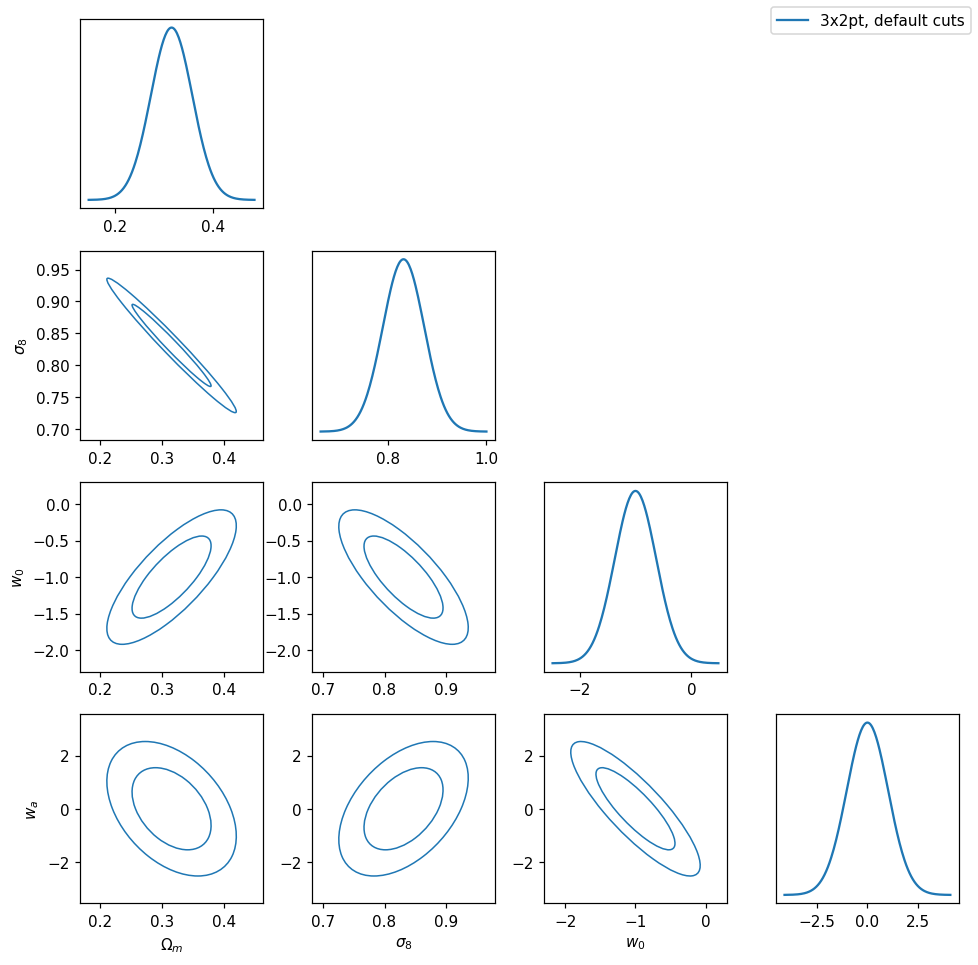

In [8]:
params = ["omega_m", "sigma_8", "w_0", "w_a"]
fig = res_y1_cs.corner(params, color="C0", label="3x2pt, default cuts")
# fig = res_cut.corner(params, color="C3", label="3x2pt, $\\ell_{max}^{cs}=1500$", fig=fig)
fig.legend(loc="upper right", fontsize=10)
plt.show()